<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Kidney Disease Prediction**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
plt.style.use('ggplot')
%matplotlib inline

In [2]:
df = pd.read_csv('Kidney Disease Prediction - Dataset.csv')

In [3]:
pd.set_option('display.max_columns', None)
df.head(10)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,74.0,25.0,1.1,142.0,3.2,12.2,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,100.0,54.0,24.0,104.0,4.0,12.4,36,NaN,NaN,no,no,no,good,no,no,ckd
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,410.0,31.0,1.1,NaN,NaN,12.4,44,6900,5,no,yes,no,good,yes,no,ckd
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,138.0,60.0,1.9,NaN,NaN,10.8,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.0,107.0,7.2,114.0,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [4]:
df['classification'].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [5]:
df.shape

(400, 26)

In [6]:
df.drop('id', axis = 1, inplace = True)

In [7]:
df.head(10)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,74.0,25.0,1.1,142.0,3.2,12.2,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,100.0,54.0,24.0,104.0,4.0,12.4,36,NaN,NaN,no,no,no,good,no,no,ckd
7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,410.0,31.0,1.1,NaN,NaN,12.4,44,6900,5,no,yes,no,good,yes,no,ckd
8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,138.0,60.0,1.9,NaN,NaN,10.8,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.0,107.0,7.2,114.0,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [8]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
              'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'blood_glucose_random',
              'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'haemoglobin',
              'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
              'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'anemia', 'class']

In [9]:
df.head(10)

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,74.0,25.0,1.1,142.0,3.2,12.2,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,100.0,54.0,24.0,104.0,4.0,12.4,36,NaN,NaN,no,no,no,good,no,no,ckd
7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,410.0,31.0,1.1,NaN,NaN,12.4,44,6900,5,no,yes,no,good,yes,no,ckd
8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,138.0,60.0,1.9,NaN,NaN,10.8,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.0,107.0,7.2,114.0,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
blood_pressure,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
specific_gravity,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
albumin,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
sugar,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
blood_glucose_random,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
blood_urea,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
serum_creatinine,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sodium,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
potassium,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [12]:
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors = 'coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors = 'coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors = 'coerce')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [14]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'anemia', 'class'],
      dtype='object')

In [15]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [16]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'anemia',
 'class']

In [17]:
num_cols

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [18]:
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

red_blood_cells: [nan 'normal' 'abnormal']
pus_cell: ['normal' 'abnormal' nan]
pus_cell_clumps: ['notpresent' 'present' nan]
bacteria: ['notpresent' 'present' nan]
hypertension: ['yes' 'no' nan]
diabetes_mellitus: ['yes' 'no' ' yes' '\tno' '\tyes' nan]
coronary_artery_disease: ['no' 'yes' '\tno' nan]
appetite: ['good' 'poor' nan]
peda_edema: ['no' 'yes' nan]
anemia: ['no' 'yes' nan]
class: ['ckd' 'ckd\t' 'notckd']


In [19]:
df['diabetes_mellitus'].replace(to_replace = {'\tno': 'no', '\tyes': 'yes', ' yes': 'yes'}, inplace = True)
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value = 'no')
df['class'] = df['class'].replace(to_replace = {'ckd\t': 'ckd', 'notckd': 'not ckd'})

In [20]:
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

red_blood_cells: [nan 'normal' 'abnormal']
pus_cell: ['normal' 'abnormal' nan]
pus_cell_clumps: ['notpresent' 'present' nan]
bacteria: ['notpresent' 'present' nan]
hypertension: ['yes' 'no' nan]
diabetes_mellitus: ['yes' 'no' nan]
coronary_artery_disease: ['no' 'yes' nan]
appetite: ['good' 'poor' nan]
peda_edema: ['no' 'yes' nan]
anemia: ['no' 'yes' nan]
class: ['ckd' 'not ckd']


In [21]:
df['class'] = df['class'].map({'ckd': 0, 'not ckd': 1})
df['class'] = pd.to_numeric(df['class'], errors = 'coerce')
df['class'].value_counts()

class
0    250
1    150
Name: count, dtype: int64

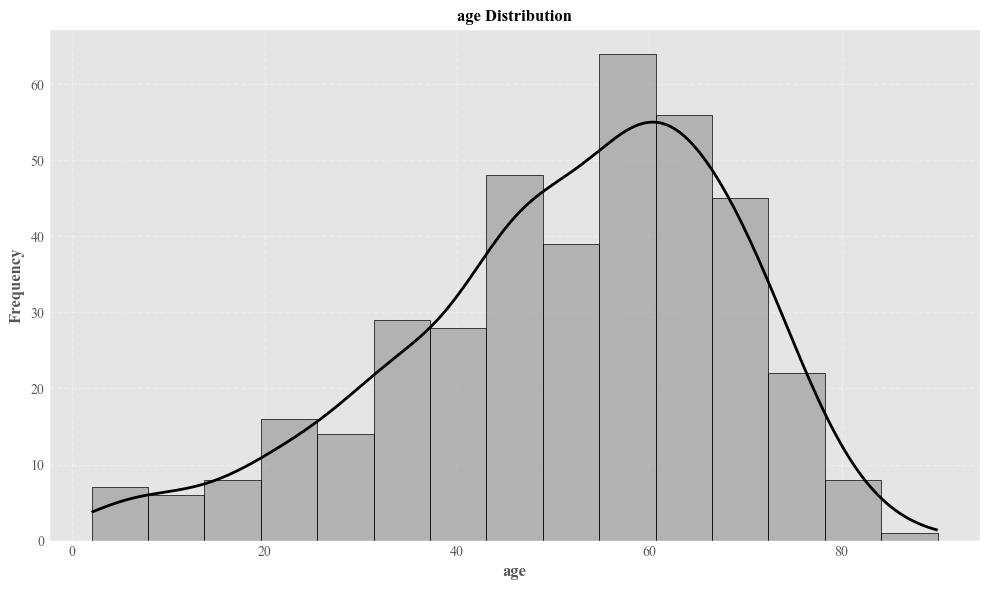

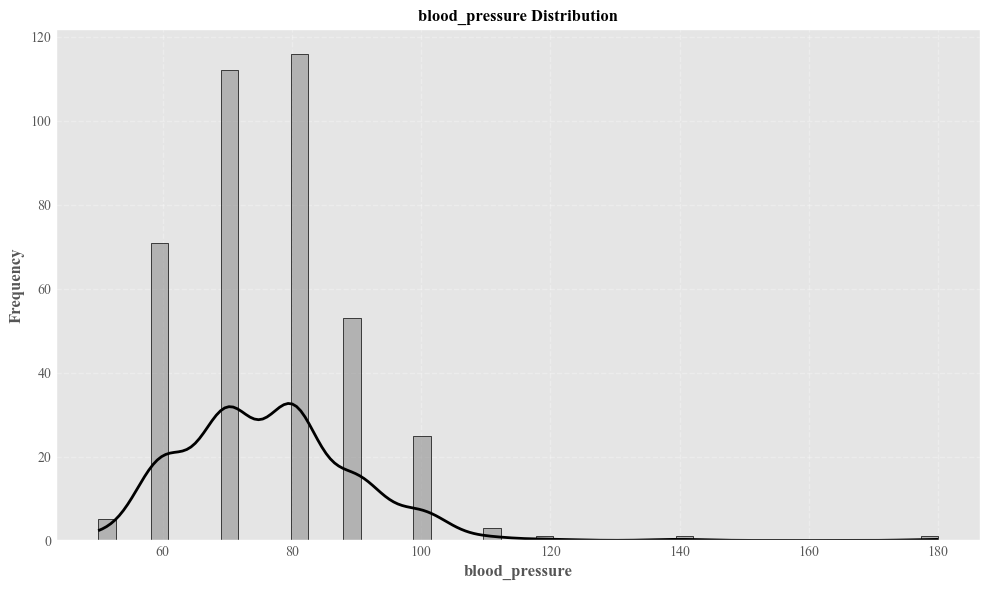

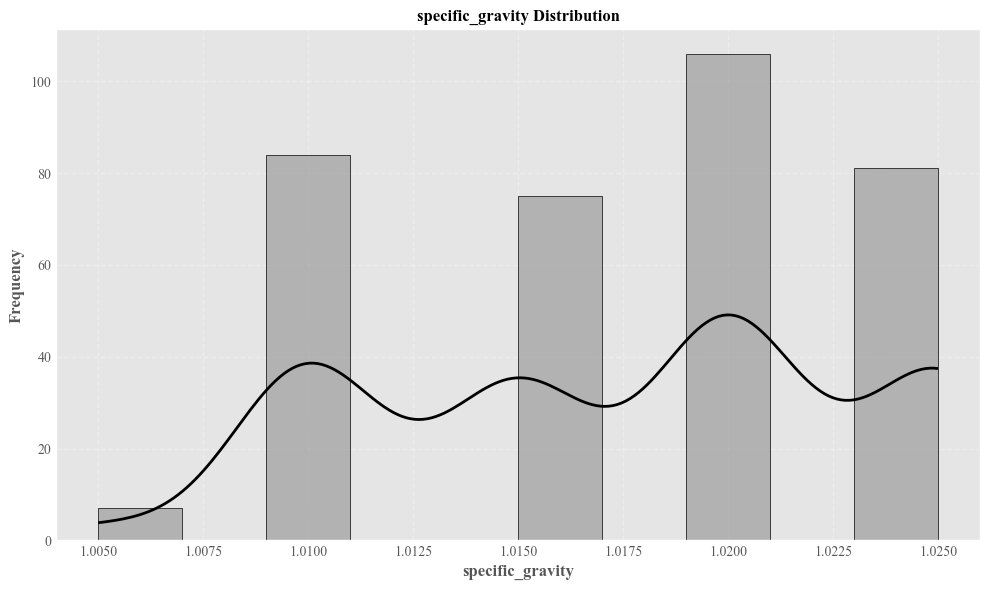

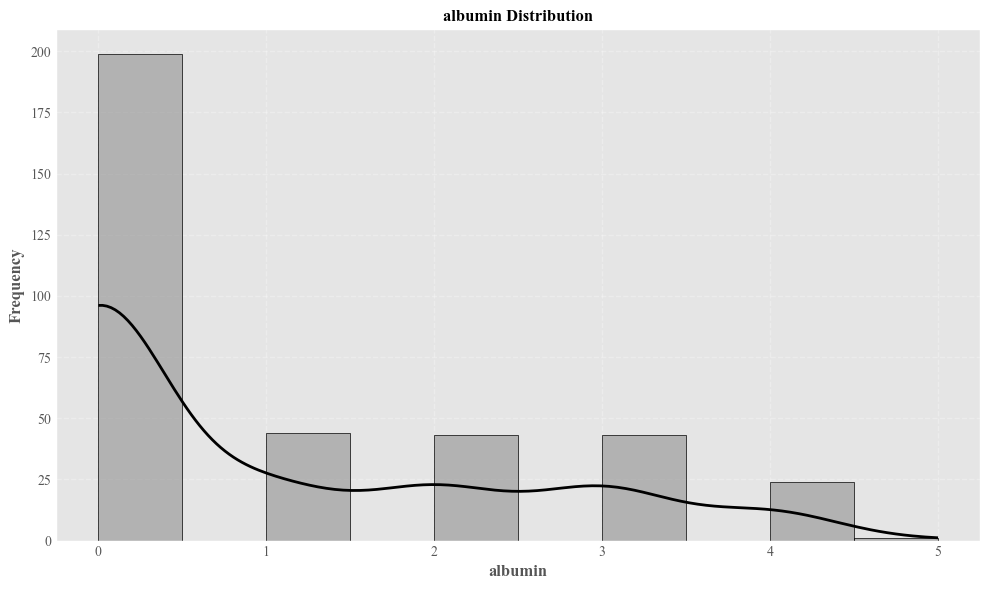

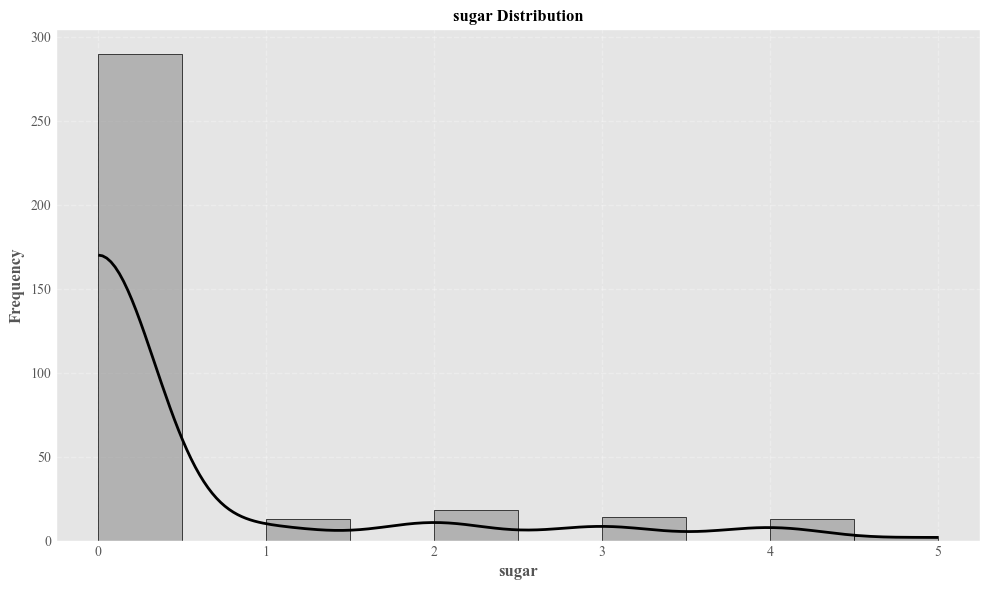

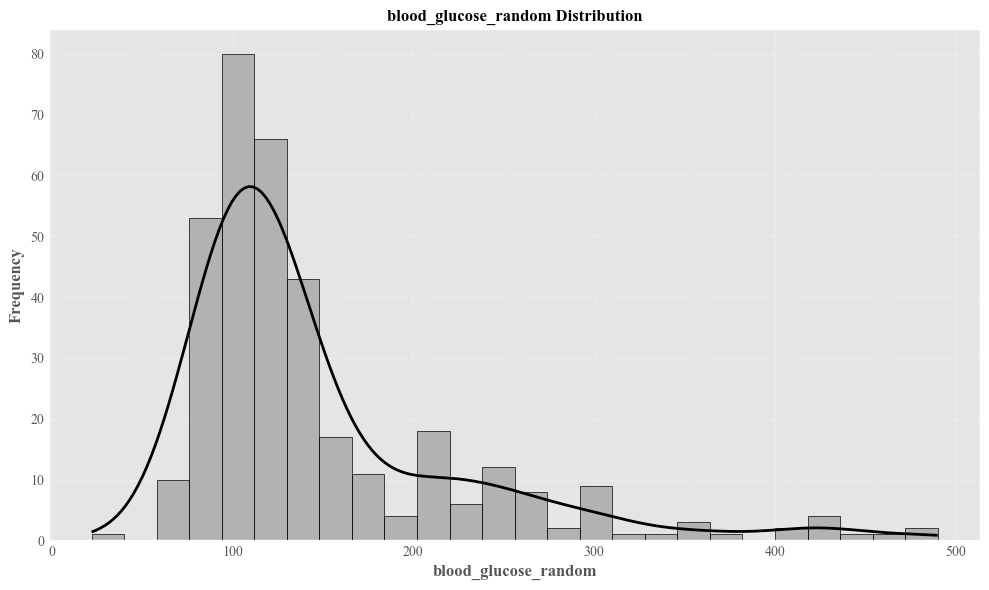

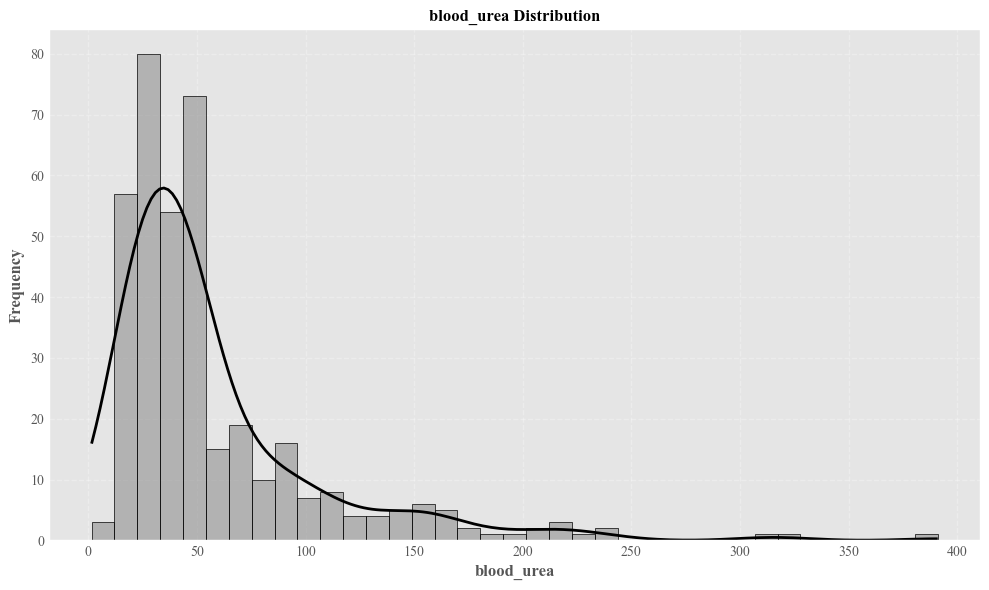

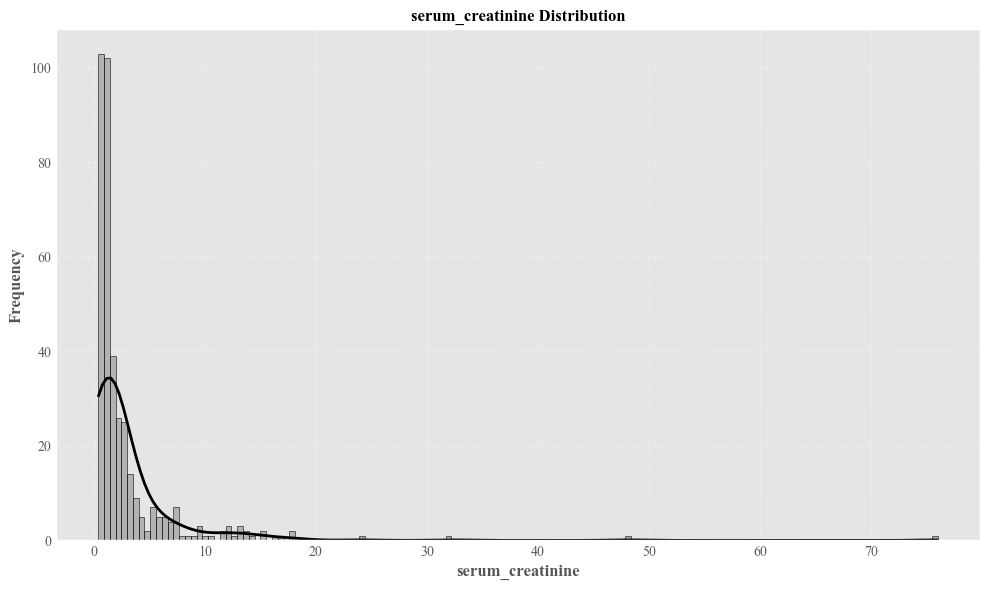

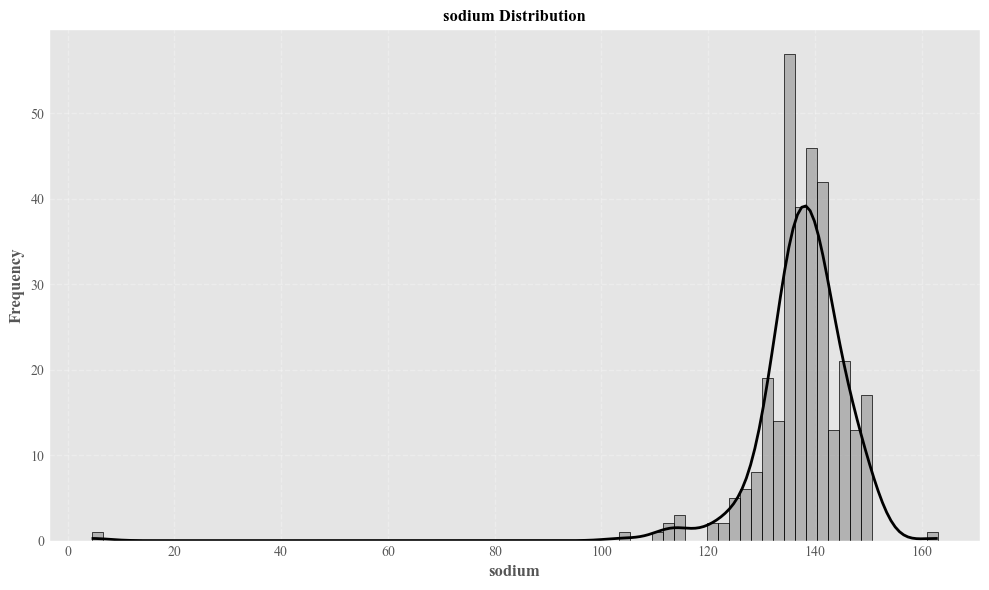

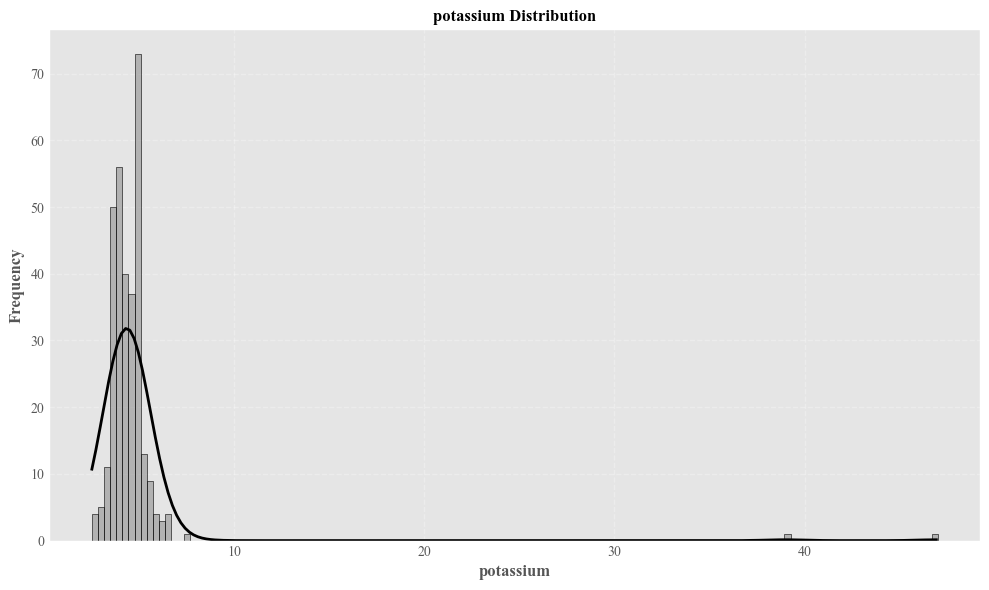

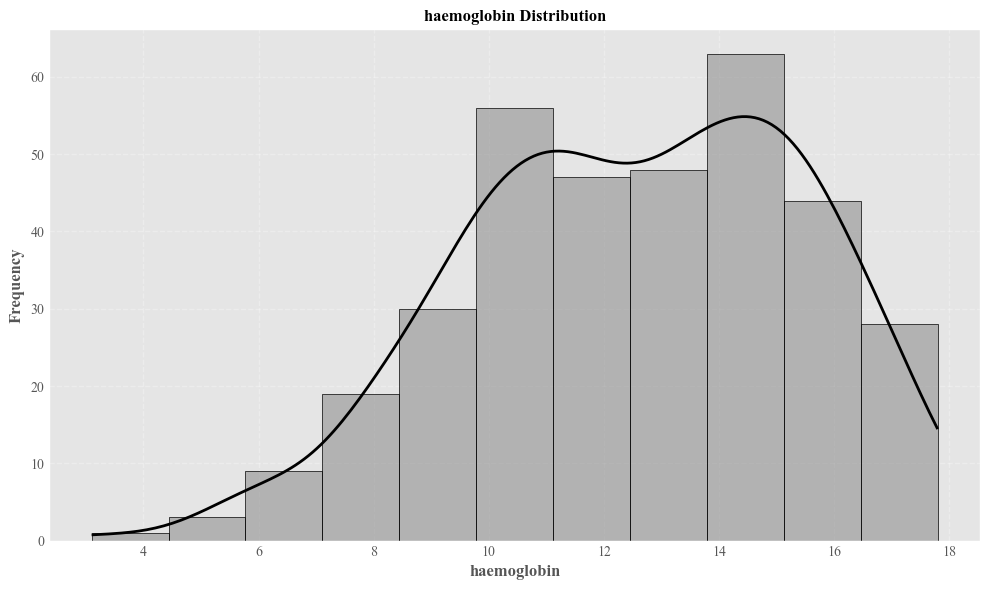

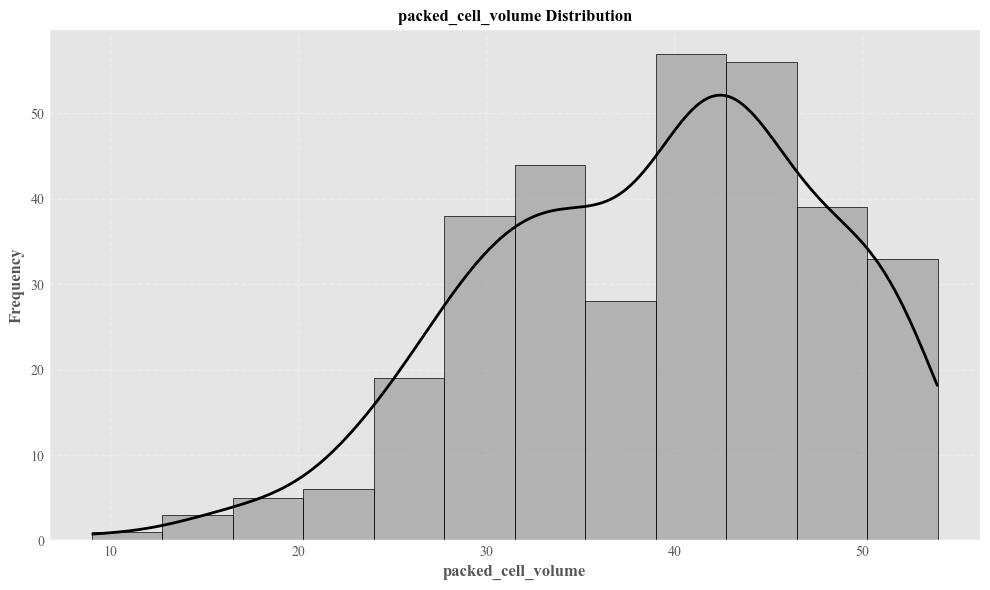

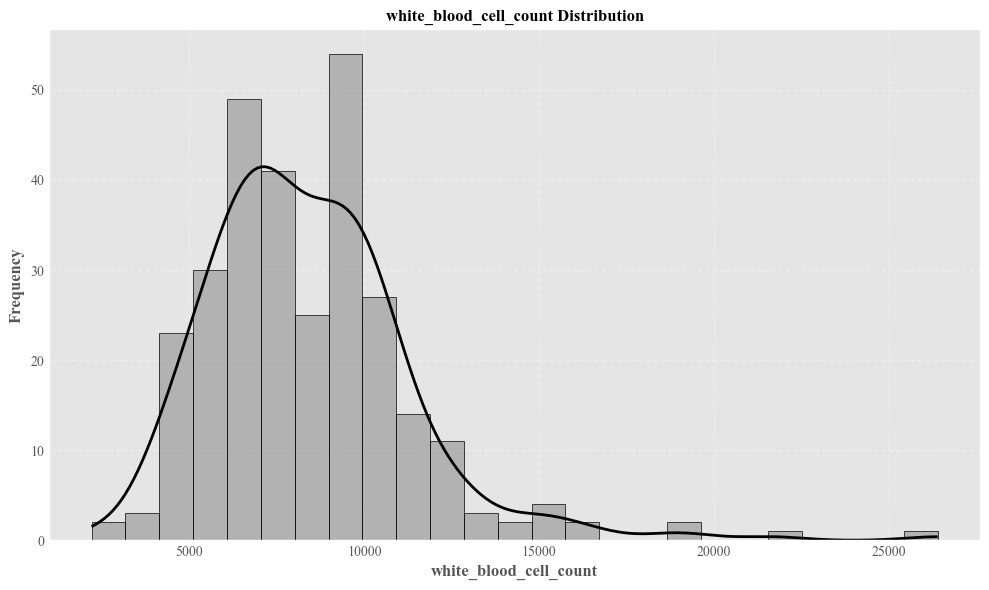

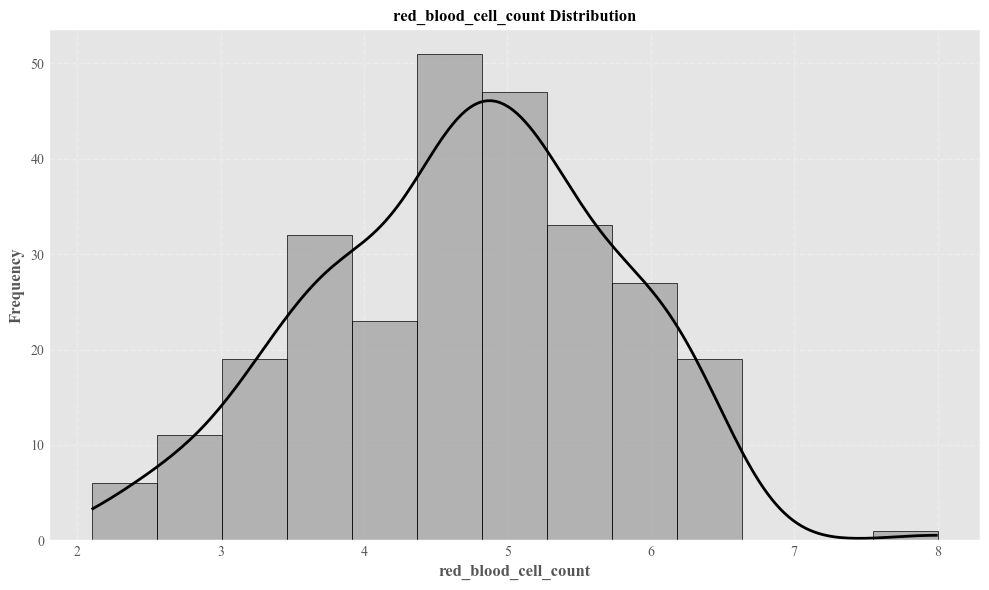

In [22]:
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'

plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        fig, ax = plt.subplots(figsize = (10, 6))
        sns.histplot(df[column], kde = True, color = 'grey', edgecolor = 'black', ax = ax)
        if ax.lines:
            ax.lines[0].set_color('black')
            ax.lines[0].set_linewidth(2)
        ax.set_title(f'{column} Distribution', fontweight = 'bold', fontsize = 12)
        ax.set_xlabel(column, fontweight = 'bold')
        ax.set_ylabel('Frequency', fontweight = 'bold')
        ax.grid(True, linestyle = '--', alpha = 0.3)
        plt.tight_layout()
        plt.show()
        
    plotnumber += 1

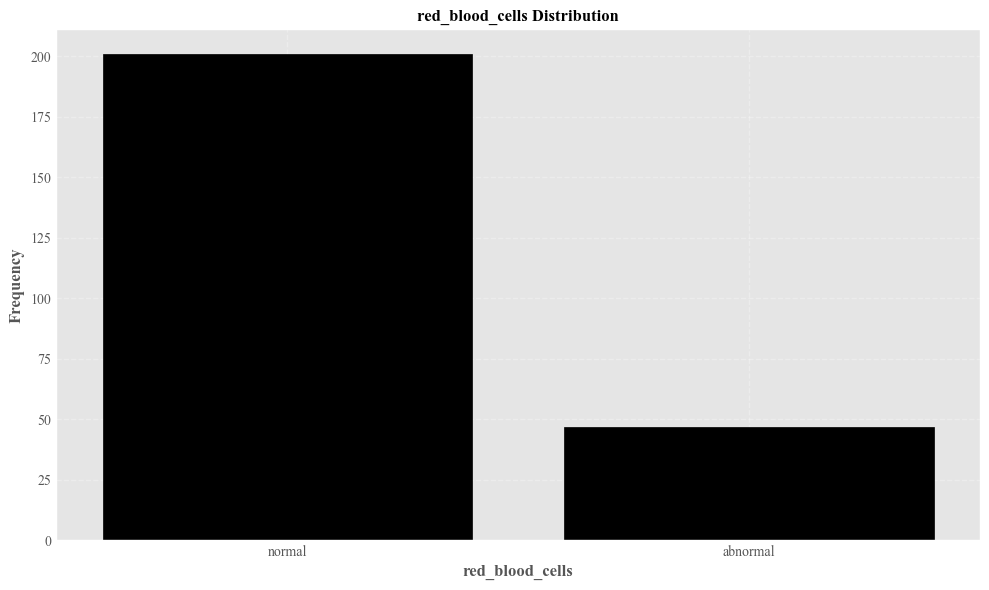

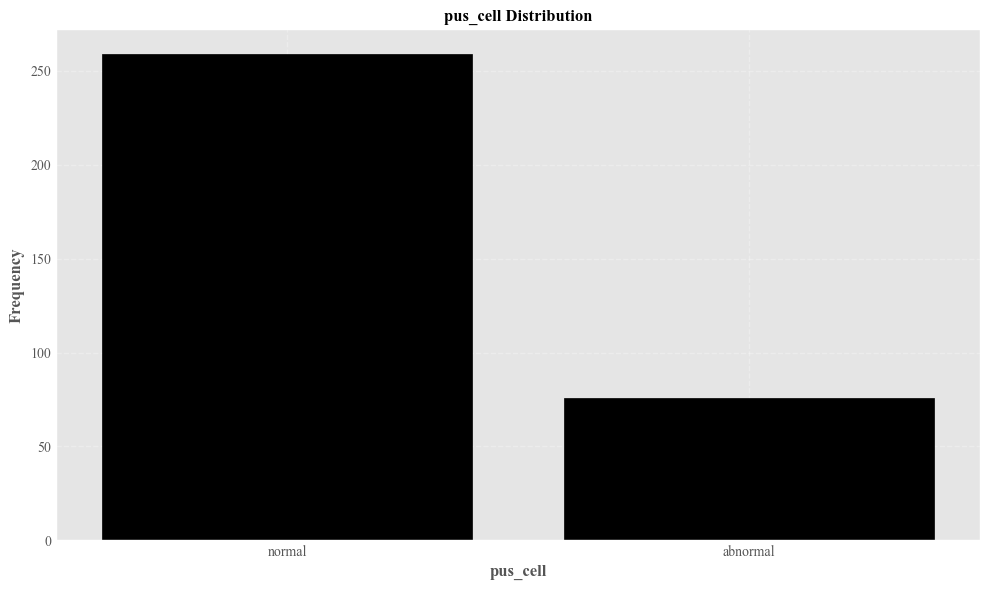

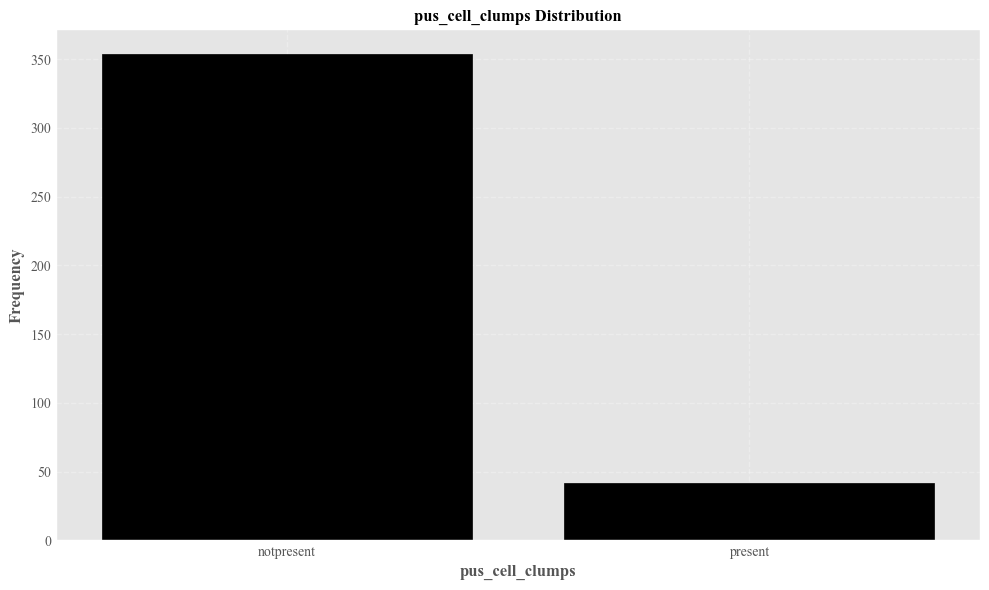

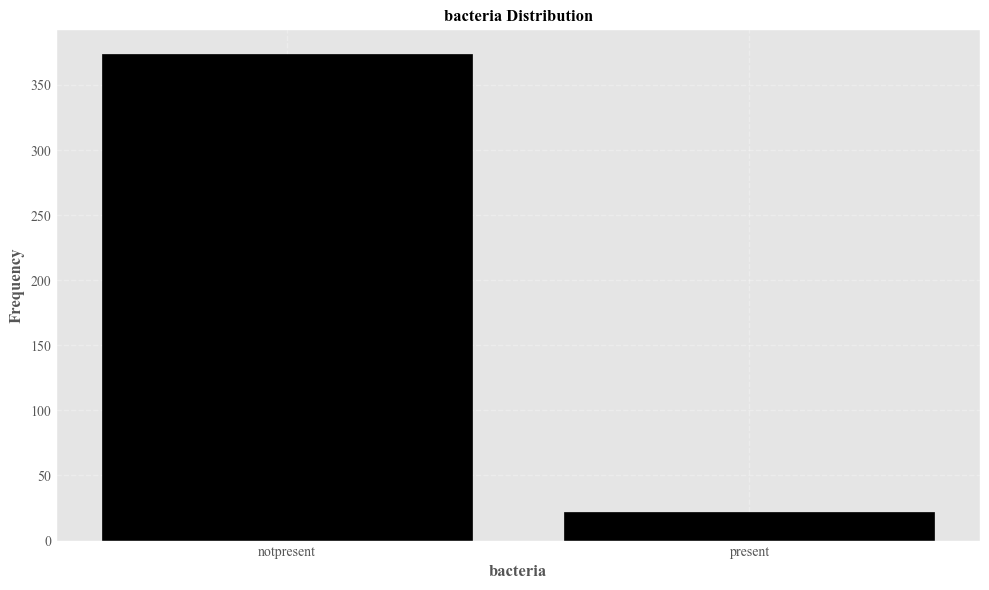

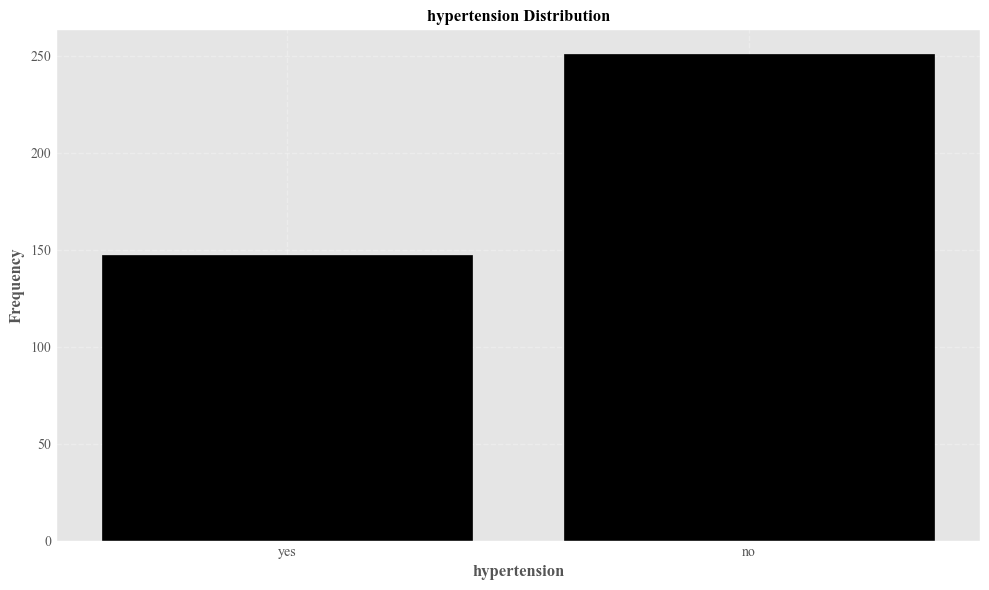

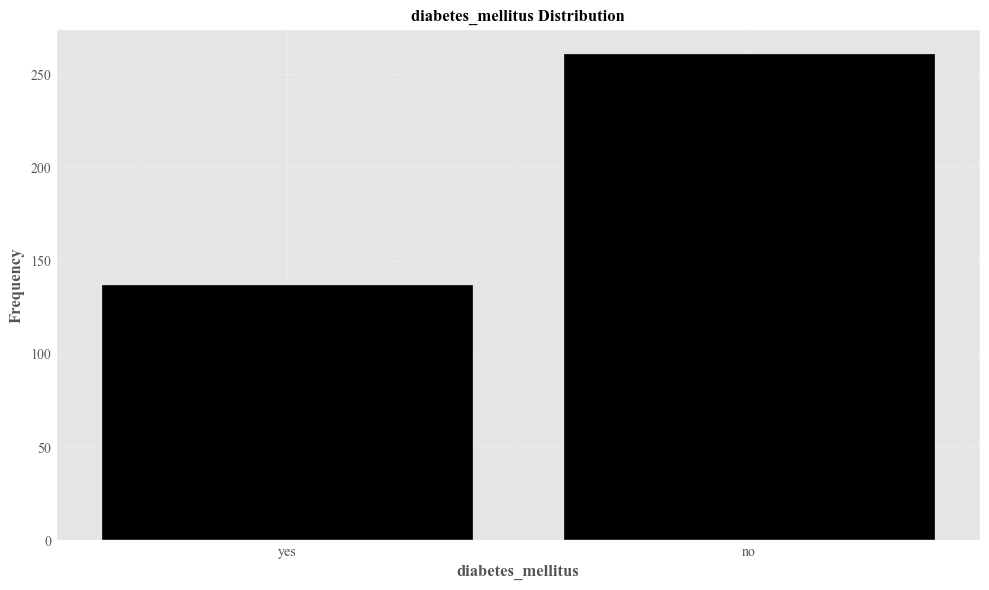

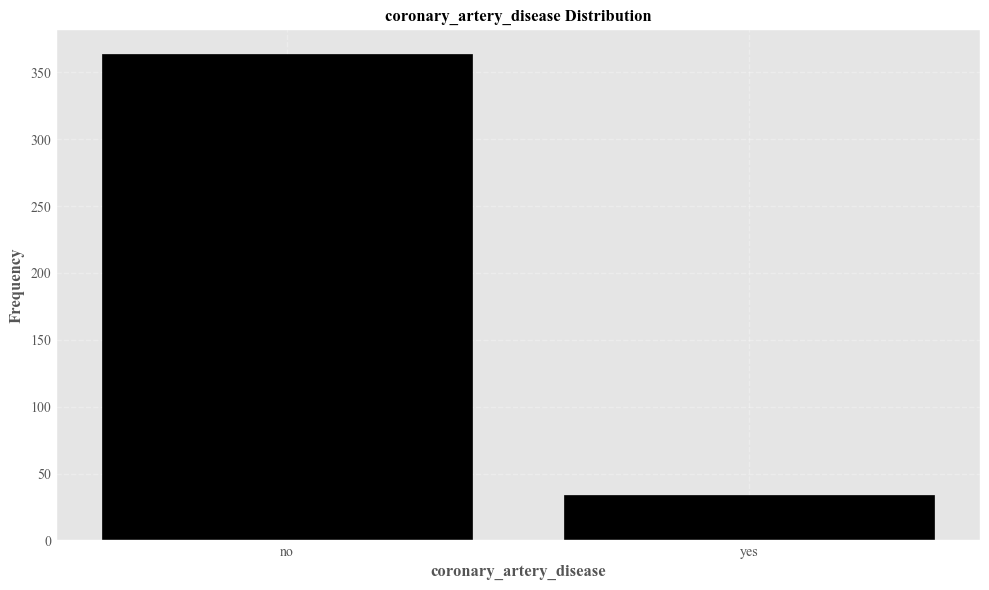

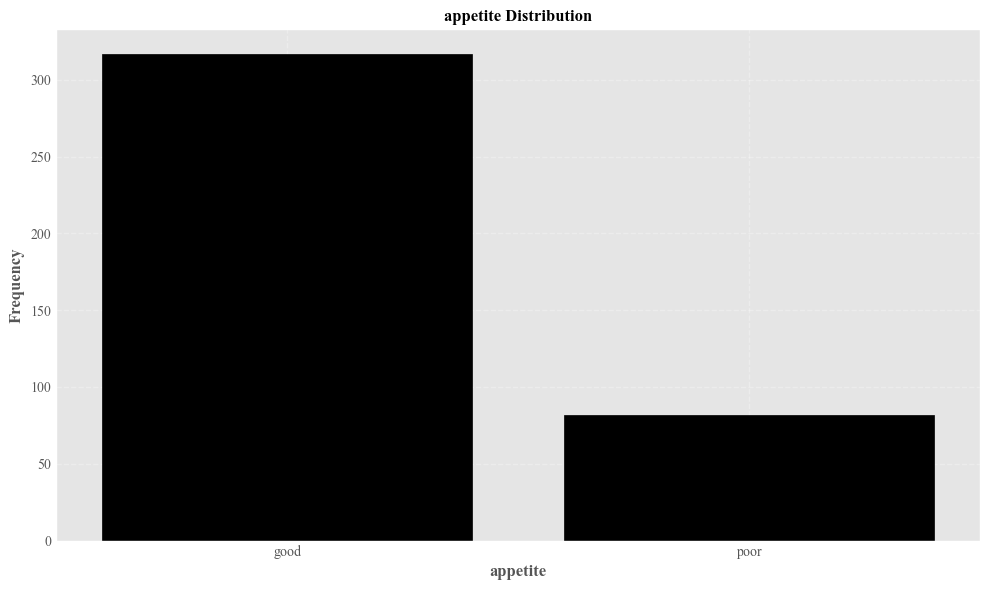

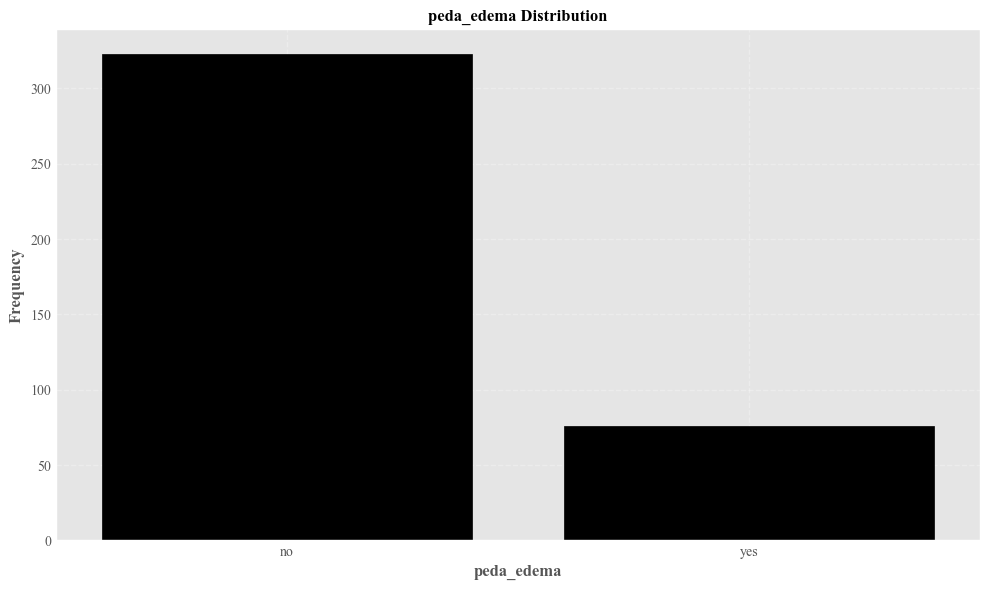

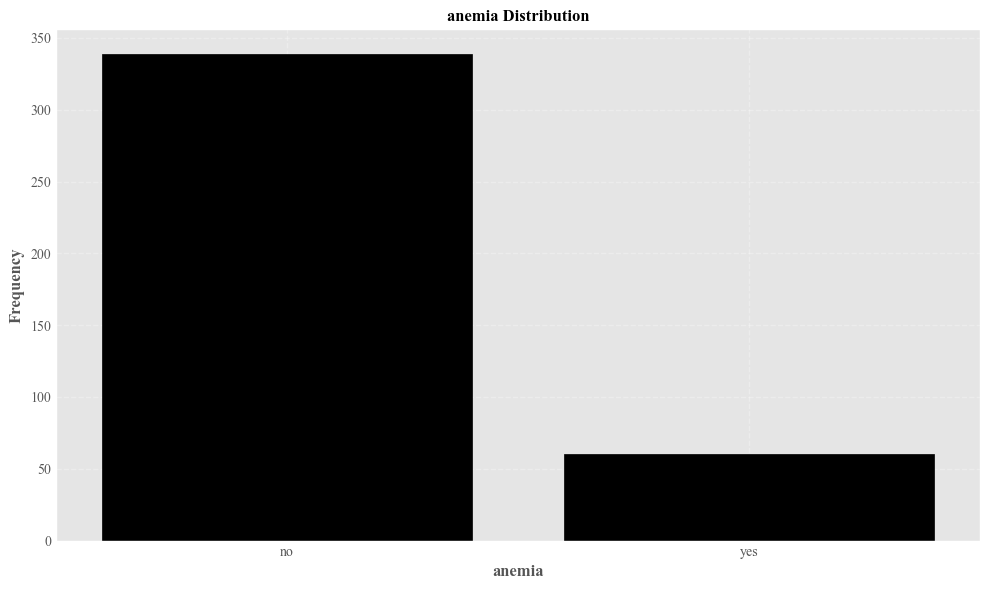

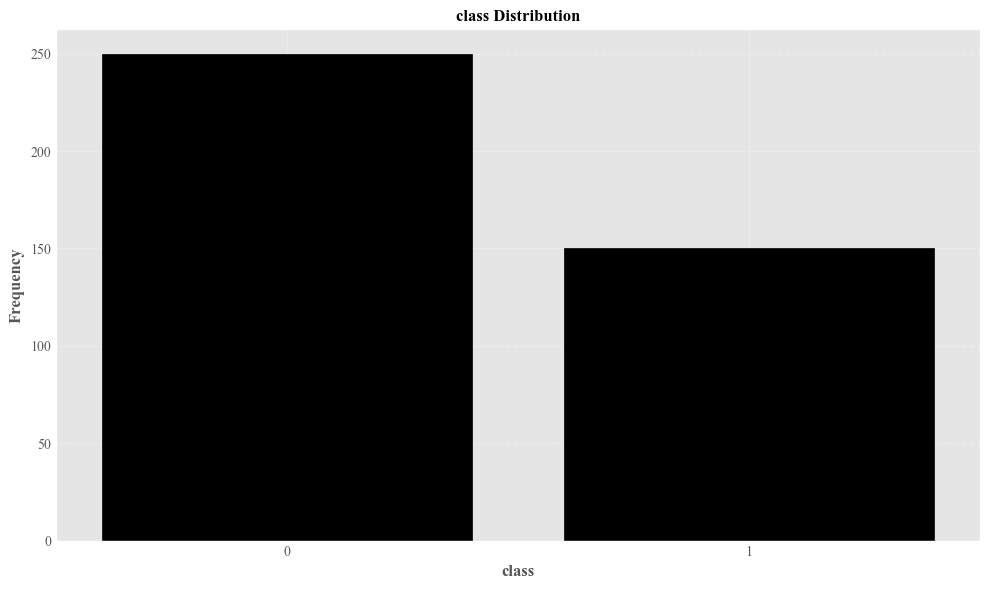

In [23]:
plotnumber = 1

for column in cat_cols:
    if plotnumber <= 14:
        fig, ax = plt.subplots(figsize = (10, 6))
        sns.countplot(x = df[column], color = 'black', edgecolor = 'black', ax = ax)
        ax.set_title(f'{column} Distribution', fontweight = 'bold', fontsize = 12)
        ax.set_xlabel(column, fontweight = 'bold')
        ax.set_ylabel('Frequency', fontweight = 'bold')
        ax.grid(True, linestyle = '--', alpha = 0.3)
        plt.tight_layout()
        plt.show()
        
    plotnumber += 1

In [24]:
df.dtypes

age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells             object
pus_cell                    object
pus_cell_clumps             object
bacteria                    object
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume         float64
white_blood_cell_count     float64
red_blood_cell_count       float64
hypertension                object
diabetes_mellitus           object
coronary_artery_disease     object
appetite                    object
peda_edema                  object
anemia                      object
class                        int64
dtype: object

In [25]:
df.corr(numeric_only = True)

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,class
age,1.000000,0.159480,-0.191096,0.122091,0.220866,0.244992,0.196985,0.132531,-0.100046,0.058377,-0.192928,-0.242119,0.118339,-0.268896,-0.227268
blood_pressure,0.159480,1.000000,-0.218836,0.160689,0.222576,0.160193,0.188517,0.146222,-0.116422,0.075151,-0.306540,-0.326319,0.029753,-0.261936,-0.294077
specific_gravity,-0.191096,-0.218836,1.000000,-0.469760,-0.296234,-0.374710,-0.314295,-0.361473,0.412190,-0.072787,0.602582,0.603560,-0.236215,0.579476,0.732163
albumin,0.122091,0.160689,-0.469760,1.000000,0.269305,0.379464,0.453528,0.399198,-0.459896,0.129038,-0.634632,-0.611891,0.231989,-0.566437,-0.627090
sugar,0.220866,0.222576,-0.296234,0.269305,1.000000,0.717827,0.168583,0.223244,-0.131776,0.219450,-0.224775,-0.239189,0.184893,-0.237448,-0.344070
blood_glucose_random,0.244992,0.160193,-0.374710,0.379464,0.717827,1.000000,0.143322,0.114875,-0.267848,0.066966,-0.306189,-0.301385,0.150015,-0.281541,-0.419672
blood_urea,0.196985,0.188517,-0.314295,0.453528,0.168583,0.143322,1.000000,0.586368,-0.323054,0.357049,-0.610360,-0.607621,0.050462,-0.579087,-0.380605
serum_creatinine,0.132531,0.146222,-0.361473,0.399198,0.223244,0.114875,0.586368,1.000000,-0.690158,0.326107,-0.401670,-0.404193,-0.006390,-0.400852,-0.299969
sodium,-0.100046,-0.116422,0.412190,-0.459896,-0.131776,-0.267848,-0.323054,-0.690158,1.000000,0.097887,0.365183,0.376914,0.007277,0.344873,0.375674
potassium,0.058377,0.075151,-0.072787,0.129038,0.219450,0.066966,0.357049,0.326107,0.097887,1.000000,-0.133746,-0.163182,-0.105576,-0.158309,-0.084541


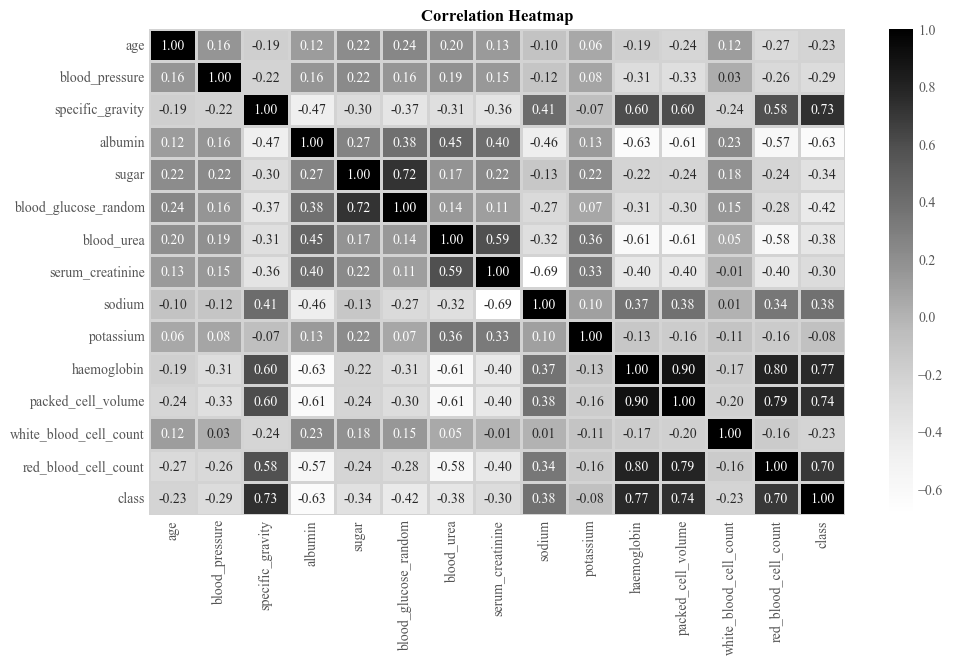

In [26]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'Greys', 
            fmt = '.2f', linewidth = 2, linecolor = 'lightgray', ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.grid(False)

plt.show()

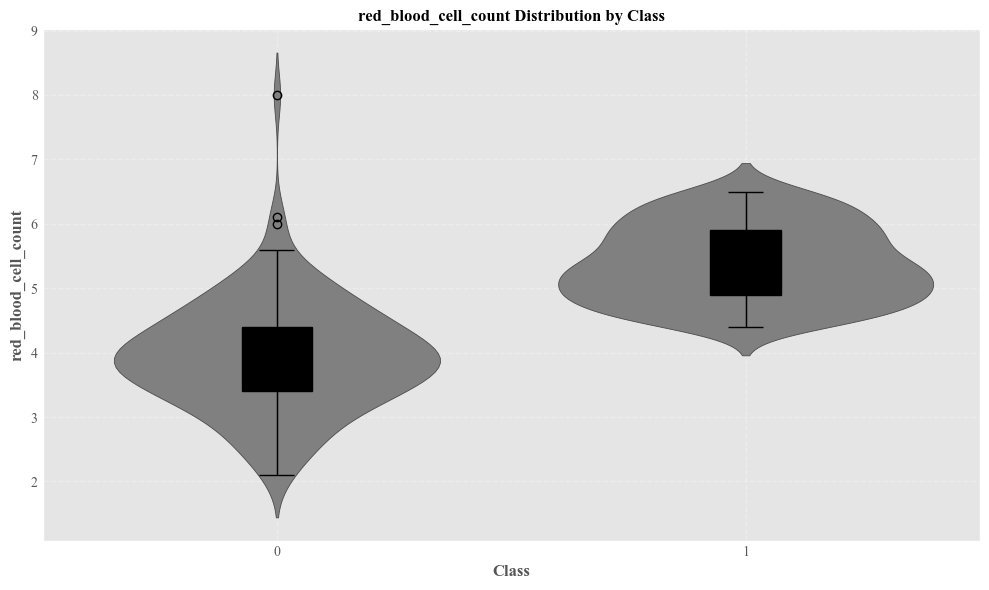

In [27]:
def violinplot(col):
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.violinplot(x = 'class', y = col, data = df, color = 'grey', ax = ax)
    sns.boxplot(x = 'class', y = col, data = df, width = 0.15, color = 'black', ax = ax)
    ax.set_title(f'{col} Distribution by Class', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('Class', fontweight = 'bold')
    ax.set_ylabel(col, fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    plt.tight_layout()
    plt.show()

violinplot('red_blood_cell_count')

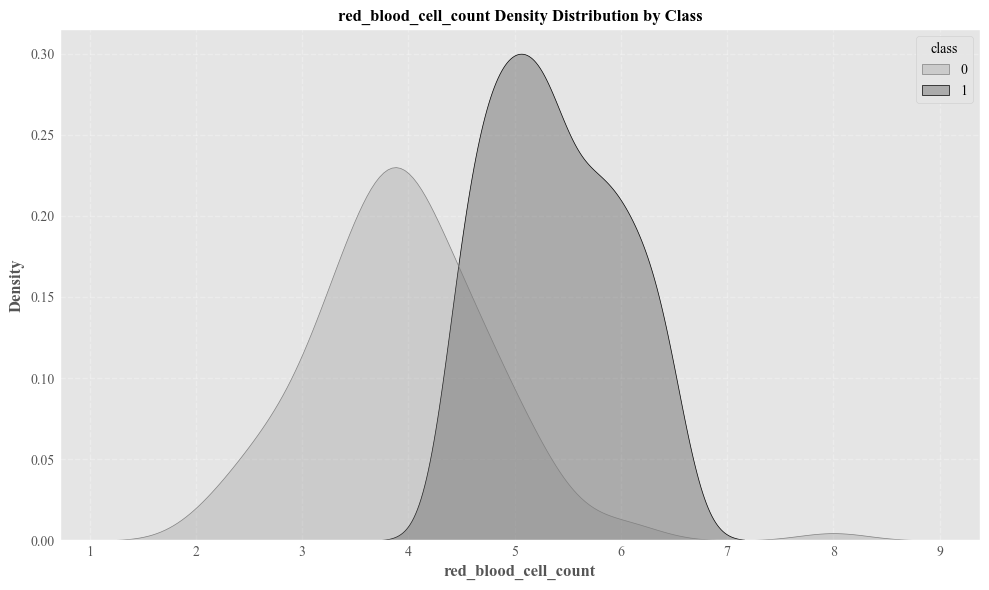

In [28]:
def kde(col):
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.kdeplot(data = df, x = col, hue = 'class', fill = True, palette = ['grey', 'black'], ax = ax)
    ax.set_title(f'{col} Density Distribution by Class', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel(col, fontweight = 'bold')
    ax.set_ylabel('Density', fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    plt.tight_layout()
    plt.show()

kde('red_blood_cell_count')

In [29]:
num_cols

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

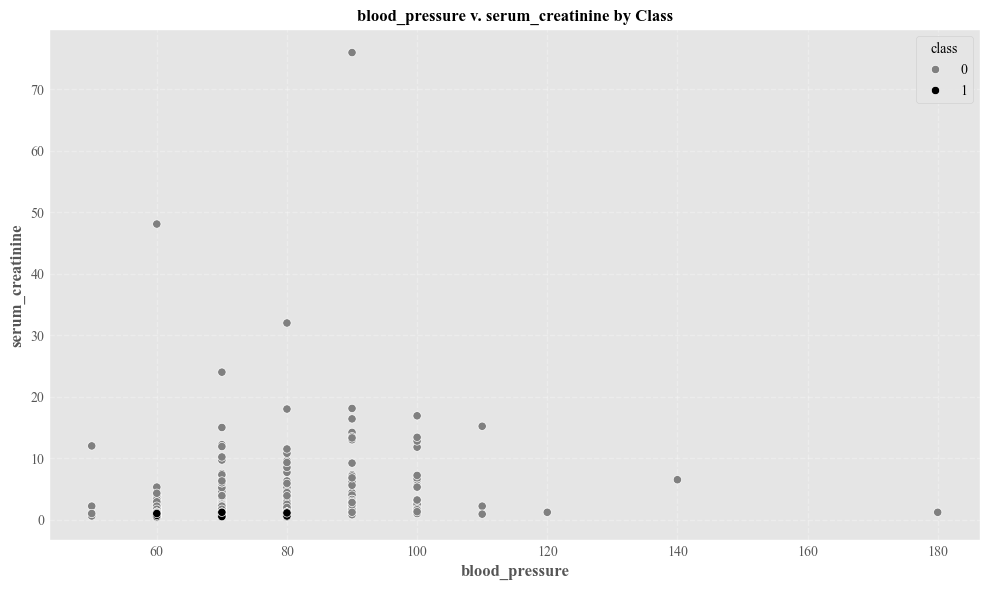

In [30]:
def scatterplot(col1, col2):
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.scatterplot(x = col1, y = col2, hue = 'class', data = df, palette = ['grey', 'black'], ax = ax)
    ax.set_title(f'{col1} v. {col2} by Class', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel(col1, fontweight = 'bold')
    ax.set_ylabel(col2, fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    plt.tight_layout()
    plt.show()

scatterplot('blood_pressure', 'serum_creatinine')

In [31]:
df.isnull().sum().sort_values(ascending = False)

red_blood_cells            152
red_blood_cell_count       131
white_blood_cell_count     106
potassium                   88
sodium                      87
packed_cell_volume          71
pus_cell                    65
haemoglobin                 52
sugar                       49
specific_gravity            47
albumin                     46
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
blood_pressure              12
age                          9
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
anemia                       1
class                        0
dtype: int64

In [32]:
df[num_cols].isnull().sum().sort_values(ascending = False)

red_blood_cell_count      131
white_blood_cell_count    106
potassium                  88
sodium                     87
packed_cell_volume         71
haemoglobin                52
sugar                      49
specific_gravity           47
albumin                    46
blood_glucose_random       44
blood_urea                 19
serum_creatinine           17
blood_pressure             12
age                         9
dtype: int64

In [33]:
df[cat_cols].isnull().sum().sort_values(ascending = False)

red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
anemia                       1
class                        0
dtype: int64

In [34]:
def random_sampling(feature):
    random_sample = df[feature].dropna().sample(df[feature].isna().sum())
    random_sample.index = df[df[feature].isnull()].index
    df.loc[df[feature].isnull(), feature] = random_sample
    
def mode_imputation(feature):
    mode = df[feature].mode()[0]
    df[feature] = df[feature].fillna(mode)

In [35]:
for col in num_cols:
    random_sampling(col)

df[num_cols].isnull().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [36]:
df.shape

(400, 25)

In [37]:
for col in cat_cols:
    mode_imputation(col)

df[cat_cols].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
anemia                     0
class                      0
dtype: int64

In [38]:
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} categories')

red_blood_cells: 2 categories
pus_cell: 2 categories
pus_cell_clumps: 2 categories
bacteria: 2 categories
hypertension: 2 categories
diabetes_mellitus: 2 categories
coronary_artery_disease: 2 categories
appetite: 2 categories
peda_edema: 2 categories
anemia: 2 categories
class: 2 categories


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [40]:
df.head(10)

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,36.0,1.2,136.0,3.6,15.4,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,158.0,18.0,0.8,139.0,5.7,11.3,38.0,6000.0,4.3,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,53.0,1.8,141.0,2.7,9.6,31.0,7500.0,6.2,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,26.0,1.4,137.0,5.4,11.6,35.0,7300.0,4.6,0,0,0,0,0,0,0
5,60.0,90.0,1.015,3.0,0.0,1,1,0,0,74.0,25.0,1.1,142.0,3.2,12.2,39.0,7800.0,4.4,1,1,0,0,1,0,0
6,68.0,70.0,1.010,0.0,0.0,1,1,0,0,100.0,54.0,24.0,104.0,4.0,12.4,36.0,10700.0,3.6,0,0,0,0,0,0,0
7,24.0,80.0,1.015,2.0,4.0,1,0,0,0,410.0,31.0,1.1,135.0,3.9,12.4,44.0,6900.0,5.0,0,1,0,0,1,0,0
8,52.0,100.0,1.015,3.0,0.0,1,0,1,0,138.0,60.0,1.9,141.0,5.0,10.8,33.0,9600.0,4.0,1,1,0,0,0,1,0
9,53.0,90.0,1.020,2.0,0.0,0,0,1,0,70.0,107.0,7.2,114.0,3.7,9.5,29.0,12100.0,3.7,1,1,0,1,0,1,0


In [41]:
outliers_overview = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_overview[col] = len(outliers)

outliers_overview

{'age': 7,
 'blood_pressure': 37,
 'specific_gravity': 0,
 'albumin': 0,
 'sugar': 65,
 'blood_glucose_random': 35,
 'blood_urea': 40,
 'serum_creatinine': 53,
 'sodium': 17,
 'potassium': 4,
 'haemoglobin': 1,
 'packed_cell_volume': 1,
 'white_blood_cell_count': 13,
 'red_blood_cell_count': 1}

In [42]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'anemia',
 'class']

In [43]:
categorical_df = df[['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
                    'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
                    'peda_edema', 'anemia']]
categorical_df.head()

,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia
0,1,1,0,0,1,1,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0
2,1,1,0,0,0,1,0,1,0,1
3,1,0,1,0,1,0,0,1,1,1
4,1,1,0,0,0,0,0,0,0,0


In [44]:
y = df['class']
X = df.drop(['red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
             'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
             'peda_edema', 'anemia', 'class'], axis = 1)

num_cols = X.columns
index = X.index
X.head()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,136.0,3.6,15.4,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,0.0,158.0,18.0,0.8,139.0,5.7,11.3,38.0,6000.0,4.3
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,141.0,2.7,9.6,31.0,7500.0,6.2
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,137.0,5.4,11.6,35.0,7300.0,4.6


In [45]:
from sklearn.preprocessing import RobustScaler

transformer = RobustScaler().fit(X)
X = transformer.transform(X)
X = pd.DataFrame(X, columns = num_cols, index = index)
X.head()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count
0,-0.304348,0.0,0.0,0.5,0.0,0.000000,-0.128205,0.000000,-0.285714,-0.727273,0.606383,0.307692,-0.029412,0.2500
1,-2.086957,-3.0,0.0,2.0,0.0,0.560606,-0.589744,-0.210526,0.142857,1.181818,-0.265957,-0.153846,-0.558824,-0.3125
2,0.304348,0.0,-1.0,1.0,3.0,4.575758,0.307692,0.315789,0.428571,-1.545455,-0.627660,-0.692308,-0.117647,0.8750
3,-0.304348,-1.0,-1.5,2.0,0.0,-0.060606,0.384615,1.368421,-3.857143,-1.727273,-0.287234,-0.615385,-0.352941,-0.5625
4,-0.173913,0.0,-1.0,1.0,0.0,-0.227273,-0.384615,0.105263,-0.142857,0.909091,-0.202128,-0.384615,-0.176471,-0.1250


In [46]:
X = pd.concat([X, categorical_df], axis = 1)
X.head()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,anemia
0,-0.304348,0.0,0.0,0.5,0.0,0.000000,-0.128205,0.000000,-0.285714,-0.727273,0.606383,0.307692,-0.029412,0.2500,1,1,0,0,1,1,0,0,0,0
1,-2.086957,-3.0,0.0,2.0,0.0,0.560606,-0.589744,-0.210526,0.142857,1.181818,-0.265957,-0.153846,-0.558824,-0.3125,1,1,0,0,0,0,0,0,0,0
2,0.304348,0.0,-1.0,1.0,3.0,4.575758,0.307692,0.315789,0.428571,-1.545455,-0.627660,-0.692308,-0.117647,0.8750,1,1,0,0,0,1,0,1,0,1
3,-0.304348,-1.0,-1.5,2.0,0.0,-0.060606,0.384615,1.368421,-3.857143,-1.727273,-0.287234,-0.615385,-0.352941,-0.5625,1,0,1,0,1,0,0,1,1,1
4,-0.173913,0.0,-1.0,1.0,0.0,-0.227273,-0.384615,0.105263,-0.142857,0.909091,-0.202128,-0.384615,-0.176471,-0.1250,1,1,0,0,0,0,0,0,0,0


In [47]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: class, Length: 400, dtype: int64

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print('K-Nearest Neighbours')
print(f'Training Accuracy: {accuracy_score(y_train, knn.predict(X_train))}')
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, knn.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

K-Nearest Neighbours
Training Accuracy: 0.94375
Test Accuracy: 0.9
Confusion Matrix: [[43  7]
 [ 1 29]]
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.86      0.91        50
           1       0.81      0.97      0.88        30

    accuracy                           0.90        80
   macro avg       0.89      0.91      0.90        80
weighted avg       0.91      0.90      0.90        80



In [50]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print('Logistic Regression')
print(f'Training Accuracy: {accuracy_score(y_train, log_reg.predict(X_train))}')
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, log_reg.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Logistic Regression
Training Accuracy: 0.9875
Test Accuracy: 0.9625
Confusion Matrix: [[49  1]
 [ 2 28]]
Classification Report:               precision    recall  f1-score   support

           0       0.96      0.98      0.97        50
           1       0.97      0.93      0.95        30

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



In [51]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold


svc = SVC(probability = True)

svc_params = {'gamma': [0.0001, 0.001, 0.01, 0.1],
              'C': [0.01, 0.05, 0.5, 1, 10, 15, 20]}

svc_grid_search = GridSearchCV(svc, param_grid = svc_params)
svc_grid_search.fit(X_train, y_train)

GridSearchCV(estimator=SVC(probability=True),
             param_grid={'C': [0.01, 0.05, 0.5, 1, 10, 15, 20],
                         'gamma': [0.0001, 0.001, 0.01, 0.1]})

In [52]:
svc_grid_search.best_params_

{'C': 1, 'gamma': 0.001}

In [53]:
print(svc_grid_search.best_score_)

0.98125


In [54]:
svc = svc_grid_search.best_estimator_
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
print('Support Vector Machine')
print(f'Training Accuracy: {accuracy_score(y_train, svc.predict(X_train))}')
svc_acc = accuracy_score(y_test, svc.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, svc.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Support Vector Machine
Training Accuracy: 0.959375
Test Accuracy: 0.9
Confusion Matrix: [[43  7]
 [ 1 29]]
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.86      0.91        50
           1       0.81      0.97      0.88        30

    accuracy                           0.90        80
   macro avg       0.89      0.91      0.90        80
weighted avg       0.91      0.90      0.90        80



In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

dt = DecisionTreeClassifier()

dt_params = {'criterion': ['gini', 'entropy'],
             'max_depth': [3, 5, 7, 10],
             'splitter': ['best', 'random'],
             'min_samples_leaf': [1, 2, 3, 5, 7],
             'min_samples_split': [1, 2, 3, 5, 7],
             'max_features': ['auto', 'sqrt', 'log2']}

dt_grid_search = GridSearchCV(dt, param_grid = dt_params, cv = 50, n_jobs = -1, verbose = 1)
dt_grid_search.fit(X_train, y_train)

Fitting 50 folds for each of 1200 candidates, totalling 60000 fits


GridSearchCV(cv=50, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3, 5, 7],
                         'min_samples_split': [1, 2, 3, 5, 7],
                         'splitter': ['best', 'random']},
             verbose=1)

In [56]:
dt_grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 7,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'splitter': 'best'}

In [57]:
print(dt_grid_search.best_score_)

0.9847619047619048


In [58]:
dt = dt_grid_search.best_estimator_
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print('Decision Tree')
print(f'Training Accuracy: {accuracy_score(y_train, dt.predict(X_train))}')
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, dt.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Decision Tree
Training Accuracy: 0.984375
Test Accuracy: 0.95
Confusion Matrix: [[49  1]
 [ 3 27]]
Classification Report:               precision    recall  f1-score   support

           0       0.94      0.98      0.96        50
           1       0.96      0.90      0.93        30

    accuracy                           0.95        80
   macro avg       0.95      0.94      0.95        80
weighted avg       0.95      0.95      0.95        80



In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

rf = RandomForestClassifier(criterion = 'entropy', max_depth = 10, min_samples_leaf = 2, 
                            min_samples_split = 7, n_estimators = 130, max_features = 'log2')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Random Forest')
print(f'Training Accuracy: {accuracy_score(y_train, rf.predict(X_train))}')
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, rf.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Random Forest
Training Accuracy: 0.99375
Test Accuracy: 0.975
Confusion Matrix: [[50  0]
 [ 2 28]]
Classification Report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



In [60]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

gbc = GradientBoostingClassifier()

gbc_params = {'loss': ['deviance', 'exponential'],
              'learning_rate': [0.001, 0.1, 1, 10],
              'n_estimators': [100, 150, 180, 200],
              'criterion': ['friedman_mse', 'squared_error']}

gbc_grid_search = GridSearchCV(gbc, param_grid = gbc_params, cv = 10, n_jobs = -1, verbose = 1)
gbc_grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 64 candidates, totalling 640 fits


GridSearchCV(cv=10, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'criterion': ['friedman_mse', 'squared_error'],
                         'learning_rate': [0.001, 0.1, 1, 10],
                         'loss': ['deviance', 'exponential'],
                         'n_estimators': [100, 150, 180, 200]},
             verbose=1)

In [61]:
gbc_grid_search.best_params_

{'criterion': 'friedman_mse',
 'learning_rate': 0.1,
 'loss': 'exponential',
 'n_estimators': 100}

In [62]:
print(gbc_grid_search.best_score_)

0.984375


In [63]:
gbc = gbc_grid_search.best_estimator_
gbc.fit(X_train, y_train)
y_pred = gbc.predict(X_test)
print('Gradient Boosting Classifier')
print(f'Training Accuracy: {accuracy_score(y_train, gbc.predict(X_train))}')
gbc_acc = accuracy_score(y_test, gbc.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, gbc.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Gradient Boosting Classifier
Training Accuracy: 1.0
Test Accuracy: 0.9375
Confusion Matrix: [[49  1]
 [ 4 26]]
Classification Report:               precision    recall  f1-score   support

           0       0.92      0.98      0.95        50
           1       0.96      0.87      0.91        30

    accuracy                           0.94        80
   macro avg       0.94      0.92      0.93        80
weighted avg       0.94      0.94      0.94        80



In [64]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

xgb = XGBClassifier(objective = 'binary:logistic', learning_rate = 1, max_depth = 10, n_estimators = 150)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
print('XGBoost Classifier')
print(f'Training Accuracy: {accuracy_score(y_train, xgb.predict(X_train))}')
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, xgb.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

XGBoost Classifier
Training Accuracy: 1.0
Test Accuracy: 0.975
Confusion Matrix: [[50  0]
 [ 2 28]]
Classification Report:               precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



In [65]:
import sys
!{sys.executable} -m pip install scipy

In [66]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from scipy.stats import loguniform

mlp = MLPClassifier(random_state = 42)

mlp_params = {'activation': ['logistic', 'tanh', 'relu'],
              'solver': ['sgd', 'adam'],
              'alpha': loguniform(1e-6, 1e-2),
              'learning_rate_init': loguniform(1e-5, 1e-1),
              'learning_rate': ['constant', 'adaptive'],
              'max_iter': [200, 300, 500],
              'hidden_layer_sizes': [(50,), (100,), (100, 50), (128, 64), (256, 128, 64)],
              'batch_size': [32, 64, 128],
              'early_stopping': [True]}

random_search_mlp = RandomizedSearchCV(estimator = mlp, param_distributions = mlp_params,
                                       n_iter = 50, cv = 5, scoring = 'accuracy', random_state = 42,
                                       n_jobs = -1, verbose = 1)

random_search_mlp.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=MLPClassifier(random_state=42), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'activation': ['logistic', 'tanh',
                                                       'relu'],
                                        'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000211004D0170>,
                                        'batch_size': [32, 64, 128],
                                        'early_stopping': [True],
                                        'hidden_layer_sizes': [(50,), (100,),
                                                               (100, 50),
                                                               (128, 64),
                                                               (256, 128, 64)],
                                        'learning_rate': ['constant',
                                                          'adaptive'],
                                        'learning_rate_init': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000002117BA16540>,
                                        'max_iter': [200, 300, 500],
                                        'solver': ['sgd', 'adam']},
                   random_state=42, scoring='accuracy', verbose=1)

In [67]:
random_search_mlp.best_params_

{'activation': 'relu',
 'alpha': np.float64(0.0015352246941973493),
 'batch_size': 128,
 'early_stopping': True,
 'hidden_layer_sizes': (100, 50),
 'learning_rate': 'adaptive',
 'learning_rate_init': np.float64(0.0024810409748678114),
 'max_iter': 500,
 'solver': 'adam'}

In [68]:
print(random_search_mlp.best_score_)

0.9875


In [69]:
mlp = random_search_mlp.best_estimator_
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
print('Multi-Layer Perceptron')
print(f'Training Accuracy: {accuracy_score(y_train, mlp.predict(X_train))}')
mlp_acc = accuracy_score(y_test, mlp.predict(X_test))
print(f'Test Accuracy: {accuracy_score(y_test, mlp.predict(X_test))}')
print(f'Confusion Matrix: {confusion_matrix(y_test, y_pred)}')
print(f'Classification Report: {classification_report(y_test, y_pred)}')

Multi-Layer Perceptron
Training Accuracy: 0.978125
Test Accuracy: 0.9375
Confusion Matrix: [[49  1]
 [ 4 26]]
Classification Report:               precision    recall  f1-score   support

           0       0.92      0.98      0.95        50
           1       0.96      0.87      0.91        30

    accuracy                           0.94        80
   macro avg       0.94      0.92      0.93        80
weighted avg       0.94      0.94      0.94        80



In [70]:
models = pd.DataFrame({'Model': ['Logistic Regression',
                                 'K-Nearest Neighbours',
                                 'Support Vector Machine',
                                 'Decision Tree',
                                 'Random Forest',
                                 'Gradient Boosting Classifier',
                                 'XGBoost Classifier',
                                 'Multi-Layer Perceptron'],
                       
                       'Score': [100 * round(log_reg_acc, 4),
                                 100 * round(knn_acc, 4),
                                 100 * round(svc_acc, 4),
                                 100 * round(dt_acc, 4),
                                 100 * round(rf_acc, 4),
                                 100 * round(gbc_acc, 4),
                                 100 * round(xgb_acc, 4),
                                 100 * round(mlp_acc, 4)]})

models.sort_values(by = 'Score', ascending = False)

,Model,Score
6,XGBoost Classifier,97.50
4,Random Forest,97.50
0,Logistic Regression,96.25
3,Decision Tree,95.00
5,Gradient Boosting Classifier,93.75
7,Multi-Layer Perceptron,93.75
2,Support Vector Machine,90.00
1,K-Nearest Neighbours,90.00


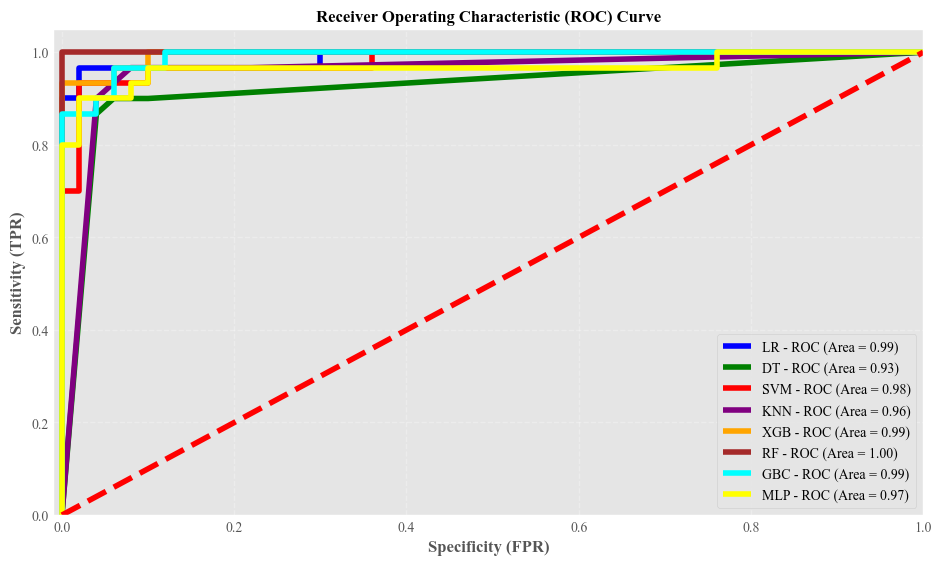

In [71]:
from sklearn import metrics

fig, ax = plt.subplots(figsize = (10, 6))

models = [{'label': 'LR', 'model': log_reg, 'color': 'blue'},
          {'label': 'DT', 'model': dt, 'color': 'green'},
          {'label': 'SVM', 'model': svc, 'color': 'red'},
          {'label': 'KNN', 'model': knn, 'color': 'purple'},
          {'label': 'XGB', 'model': xgb, 'color': 'orange'},
          {'label': 'RF', 'model': rf, 'color': 'brown'},
          {'label': 'GBC', 'model': gbc, 'color': 'cyan'},
          {'label': 'MLP', 'model': mlp, 'color': 'yellow'}]

for m in models:
    model = m['model']
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
    auc = metrics.roc_auc_score(y_test, y_pred)
    ax.plot(fpr, tpr, label = '%s - ROC (Area = %0.2f)' % (m['label'], auc), color = m['color'])

ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Specificity (FPR)', fontweight = 'bold', fontsize = 12)
ax.set_ylabel('Sensitivity (TPR)', fontweight = 'bold', fontsize = 12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontweight = 'bold', fontsize = 12)
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.legend(loc = "lower right", fontsize = 10)

plt.show()